In this notebook, we analyze the scope diversity using the iSim reported by López-Pérez, Kim, and Miranda-Quintana (Digital Discovery, 2024, 3, 1160–1171).

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..','..')))
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Code.benchmark import Benchmark
from Code.utils import obtain_full_covar_matrix
from sklearn.preprocessing import MinMaxScaler
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, Draw
from rdkit import DataStructs
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import colorsys


# Doyle colors
doyle_colors = ["#CE4C6F", "#1561C2", "#188F9D","#C4ADA2","#515798", "#CB7D85", "#A9A9A9"]
# extension of palette with lighter and darker versions
def adjust_lightness(color, factor=1.2):
    """
    Function to make colors lighter (factor > 1) or darker (factor < 1).
    """
    r, g, b = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    l = max(0, min(1, l * factor))
    r, g, b = colorsys.hls_to_rgb(h, l, s)
    return mcolors.to_hex((r, g, b))

lighter = [adjust_lightness(c, 1.2) for c in doyle_colors]
darker  = [adjust_lightness(c, 0.7) for c in doyle_colors]
all_colors = doyle_colors + darker[::-1] + lighter[::-1] 

# Save the categorical colormap
cat_cmap = ListedColormap(all_colors, name="Doyle_cat")
plt.colormaps.register(cat_cmap)

# Define and save a continuous colormap
colors = [doyle_colors[1],"#FFFFFFD1",doyle_colors[0]]
cont_cmap = LinearSegmentedColormap.from_list("Doyle_cont", colors)
plt.colormaps.register(cont_cmap)
wdir = Path(".")


# General plt parameters
plt.rcParams.update({
    "axes.titlesize": 20,        # Subplot title
    "axes.labelsize": 16,        # X and Y labels
    "figure.titlesize": 24,      # Suptitle
    "xtick.labelsize": 14,       # X tick labels
    "ytick.labelsize": 14,       # Y tick labels
    "legend.fontsize": 14,       # Legend text
    "legend.title_fontsize": 14, # Legend titles
    "font.family": "Helvetica"   # Font
    })

In [2]:
# Read in the labelled dataset
df_labelled = pd.read_csv(f"./SB_dset.csv", index_col=0,header=0)
objectives = ["rate"]
wdir = Path(".")

In [3]:
# NOTE: The functions in this cell were directly taken from the iSim package (https://github.com/mqcomplab/iSIM/tree/main)

def calculate_isim(data, n_objects = None, n_ary = 'RR'):
    """Calculate the iSIM index for RR, JT, or SM

    Arguments
    ---------
    data : np.ndarray
        Array of arrays, each sub-array contains the binary object 
        OR Array with the columnwise sum, if so specify n_objects
    
    n_objects : int
        Number of objects, only necessary if the column wize sum is the input data.

    n_ary : str
        String with the initials of the desired similarity index to calculate the iSIM from. 
        Only RR, JT, or SM are available. For other indexes use gen_sim_dict.

    Returns
    -------
    isim : float
        iSIM index for the specified similarity index.
    """

    # Check if the data is a np.ndarray of a list
    if not isinstance(data, np.ndarray):
        raise TypeError("Warning: Input data is not a np.ndarray, to secure the right results please input the right data type")
    
    if data.ndim == 1:
        c_total = data
        if not n_objects:
            raise ValueError("Input data is the columnwise sum, please specify number of objects")
    else:
        c_total = np.sum(data, axis = 0)
        if not n_objects:
            n_objects = len(data)      
        elif n_objects and n_objects != len(data):
            print("Warning, specified number of objects is different from the number of objects in data")
            n_objects = len(data)
            print("Doing calculations with", n_objects, "objects.")

    # Calculate only necessary counters for the desired index 

    if n_ary == 'RR':
        a = np.sum(c_total * (c_total - 1) / 2)
        p = n_objects * (n_objects - 1) * len(c_total) / 2

        return a/p
    
    elif n_ary == 'JT':
        a = np.sum(c_total * (c_total - 1) / 2)
        off_coincidences = n_objects - c_total
        total_dis = np.sum(off_coincidences * c_total)

        return a/(a + total_dis)
    
    elif n_ary == 'SM':
        a = np.sum(c_total * (c_total - 1) / 2)
        off_coincidences = n_objects - c_total
        d = np.sum(off_coincidences * (off_coincidences - 1) / 2)
        p = n_objects * (n_objects - 1) * len(c_total) / 2

        return (a + d)/p


def binary_fps(smiles: list, fp_type: str = 'RDKIT', n_bits: int = 2048):
    """
    This function generates binary fingerprints for the dataset.
    
    Parameters:
    smiles: list of SMILES strings
    fp_type: type of fingerprint to generate ['RDKIT', 'ECFP4', 'ECFP6', or 'MACCS']
    n_bits: number of bits for the fingerprint
    
    Returns:
    fingerprints: numpy array of fingerprints
    """
    # Generate the fingerprints
    if fp_type == 'RDKIT':
       def generate_fp(mol, fp):
            DataStructs.cDataStructs.ConvertToNumpyArray(Chem.RDKFingerprint(mol), fp)
    elif fp_type == 'ECFP4':
        def generate_fp(mol, fp):
            DataStructs.cDataStructs.ConvertToNumpyArray(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=n_bits), fp)
    elif fp_type == 'ECFP6':
        def generate_fp(mol, fp):
            DataStructs.cDataStructs.ConvertToNumpyArray(AllChem.GetMorganFingerprintAsBitVect(mol, 3, nBits=n_bits), fp)
    elif fp_type == 'MACCS':
        def generate_fp(mol, fp):
            DataStructs.cDataStructs.ConvertToNumpyArray(Chem.rdMolDescriptors.GetMACCSKeysFingerprint(mol), fp)
    else:
        print('Invalid fingerprint type: ', fp_type)
        exit(0)

    fingerprints = []
    for smi in smiles:
        # Generate the mol object
        try:
          mol = Chem.MolFromSmiles(smi)
        except:
          print('Invalid SMILES: ', smi)
          exit(0)

        # Generate the fingerprint and append to the list
        fingerprint = np.array([])
        generate_fp(mol, fingerprint)
        fingerprints.append(fingerprint)
    
    fingerprints = np.array(fingerprints)

    return fingerprints

In [4]:
def iSim_calculation(filename):
    """
    Calculate and return the iSim values for a Benchmark().collect_data() output file.
    Settings: Russel-Rao algorithm; ECFP4 fingerprint
    """

    # read in the raw data file
    df_raw = pd.read_csv(filename, index_col = 0, header = 0)
    # convert the format of the evaluated samples from one string to a list of strings
    df_raw["eval_samples"] = df_raw["eval_samples"].apply(lambda x: [y.strip("'") for y in x[1:-1].split(', ')])

    # loop through the rounds of the run
    smiles_list = []
    for run_round in df_raw.index:
        # get the evaluated samples
        samples = df_raw.loc[run_round,"eval_samples"]
        # record the evaluated samples in the df of the new featurization
        for sample in samples:
            sample = str(sample.encode().decode('unicode_escape'))
            smiles_list.append(sample)
    
    # get fingerprints and calculate iSim
    fps = binary_fps(smiles_list, fp_type="ECFP4", n_bits = 2048)
    isim = calculate_isim(fps, n_ary="RR")

    return isim

In [5]:
# Use the results of the greedy acqusition function (no pruning) with scope size 40, to get the upper bounds for the conversion and the upper bounds for the selectivity 
# and the vendi score.
dfs_bounds_greedy = {}
for metric in ["rate","vendi"]:
    dfs_metric = {}
    for batch_size in [1,2,3,4]:
        dfs_metric[batch_size] = Benchmark().heatmap_plot(type_results=metric,name_results=f"./Results_Data/bounds/greedy40_b{batch_size}",budget=40,show_plot=False)
    greedy_values = pd.concat(dfs_metric,axis=1)
    greedy_values.columns = [1,2,3,4]
    greedy_values = greedy_values.stack().reset_index(drop=True)
    dfs_bounds_greedy[metric] = pd.DataFrame({metric: greedy_values})
bounds_greedy = pd.concat(dfs_bounds_greedy,axis=1)
bounds_greedy.columns = ["rate","vendi"]
rate_max = bounds_greedy["rate"].max()
vendi_min = bounds_greedy["vendi"].min()
print(f"upper bounds rate: {rate_max}")
print(f"lower bounds vendi score: {vendi_min}")

upper bounds rate: 2.7636041685101214
lower bounds vendi score: 3.229214944957466


In [6]:
# Use the results of the explorative acqusition function (max pruning) with scope size 40, to get the lower bounds for the conversion and the lower bounds for the selectivity 
# and the upper bounds for the vendi score.
dfs_bounds_explorative = {}
for metric in ["rate","vendi"]:
    dfs_metric = {}
    for batch_size in [1,2,3,4]:
        dfs_metric[batch_size] = Benchmark().heatmap_plot(type_results=metric,
                                                          name_results=f"./Results_Data/bounds"\
                                                            f"/explorative40_b{batch_size}",
                                                            budget=40,show_plot=False)
    explorative_values = pd.concat(dfs_metric,axis=1)
    explorative_values.columns = [1,2,3,4]
    explorative_values = explorative_values.stack().reset_index(drop=True)
    dfs_bounds_explorative[metric] = pd.DataFrame({metric: explorative_values})
bounds_explorative = pd.concat(dfs_bounds_explorative,axis=1)
bounds_explorative.columns = ["rate","vendi"]
rate_min = bounds_explorative["rate"].min()
vendi_max = bounds_explorative["vendi"].max()
print(f"lower bounds rate: {rate_min}")
print(f"upper bounds vendi score: {vendi_max}")

lower bounds rate: 1.7264725188943717
upper bounds vendi score: 10.736517101249781


In [7]:
# Record the bounds
rate_bounds = (rate_max,rate_min)
vendi_bounds = (vendi_max,vendi_min)
bounds = {"rate":rate_bounds,"vendi":vendi_bounds}

Get the results

Vendi score:


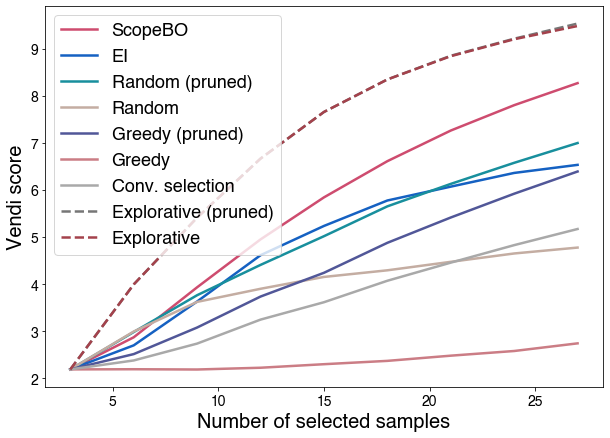

In [8]:
type_results = "Vendi"
dfs = {}
for acq in ["EI","Random","Greedy","Conv. selection","Explorative"]:
    if acq == "EI":
        acq_label = "balanced"
    elif acq == "Conv. selection":
        acq_label = "human-like-acq"
    else:
        acq_label = acq.lower()
    for pruning in [True,False]:
        if pruning:
            pruning_label = "_pruning"
            pruning_flag = "with"
        else:
            pruning_label = "_no-pruning"
            pruning_flag = "without"
        if acq == "Conv. selection":
            pruning_label = ""
        dfs_progress = Benchmark().progress_plot(budget=27, type_results= type_results,
                                    name_results=f"./Results_Data/scope_{acq_label}{pruning_label}",show_plot=False,bounds=bounds)
        dfs[acq+pruning_label] = dfs_progress["means"]
df_combined = pd.concat(dfs,axis=1)
df_combined.columns = [multiindex[0] for multiindex in df_combined.columns]
df_combined.rename(columns={"EI_pruning":"ScopeBO"},inplace=True)
df_combined = df_combined[["ScopeBO"] + [col for col in df_combined.columns if col != "ScopeBO"]]
label_dict = {col: col for col in df_combined.columns}
for key,val in label_dict.items():
    if "_no-pruning" in val:
        label_dict[key] = val.split("_")[0]
    elif "pruning" in val:
        label_dict[key] = val.split("_")[0] + " (pruned)"
df_combined.rename(columns=label_dict,inplace=True)
if type_results == "Rate":
    print("Average rate:")
else:
    print(f"{type_results} score:")
# Plot.
plt.figure(figsize=(10,7))
for j,col in enumerate(df_combined.columns):
    style = '-' if j <= 6 else '--' if j <= 13 else ':'
    plotting = df_combined[col][df_combined[col].notna()]
    plt.plot(plotting.index, plotting.values, label = col, color=all_colors[j], linestyle=style, linewidth=2.5)
plt.xlabel('Number of selected samples',fontsize=20)
plt.ylabel(f"{type_results} score",fontsize=20)
plt.legend(fontsize=18)
plt.show()

In [9]:
df_combined

,ScopeBO,EI,Random (pruned),Random,Greedy (pruned),Greedy,Conv. selection,Explorative (pruned),Explorative
3,2.190820,2.190820,2.190820,2.190820,2.190820,2.190820,2.190820,2.190820,2.190820
6,2.872310,2.701315,2.984179,2.995065,2.515656,2.194290,2.380718,3.994672,3.994672
9,3.933825,3.632086,3.765709,3.623837,3.079641,2.188544,2.738693,5.413022,5.413022
12,4.950281,4.614680,4.409057,3.901865,3.737009,2.225971,3.247641,6.665546,6.665546
15,5.842367,5.235788,5.017990,4.153494,4.241116,2.301089,3.616536,7.655400,7.655400
18,6.610767,5.776055,5.651857,4.294141,4.877732,2.371801,4.072361,8.345450,8.345450
21,7.260962,6.070109,6.128624,4.474228,5.415151,2.482144,4.456910,8.848587,8.839363
24,7.799489,6.361175,6.575819,4.651566,5.920111,2.581312,4.828497,9.210667,9.198953
27,8.267486,6.532481,6.996036,4.776657,6.391656,2.743623,5.171053,9.531599,9.479846


### Recalculate the diversity scores with iSim

In [10]:
# calculate the iSim values
isim_results = pd.DataFrame(np.nan, index=["Results"], columns=[])
for acq in ["EI","Random","Greedy","Conv. selection","Explorative"]:
    if acq == "EI":
        acq_label = "balanced"
    elif acq == "Conv. selection":
        acq_label = "human-like-acq"
    else:
        acq_label = acq.lower()
    for pruning in [True,False]:
        if pruning:
            pruning_label = "_pruning"
            pruning_flag = "with"
        else:
            pruning_label = "_no-pruning"
            pruning_flag = "without"
        if acq == "Conv. selection":
            pruning_label = ""
        isim_vals = []
        for filename in os.listdir(f"./Results_Data/scope_{acq_label}{pruning_label}/raw_data"):
            isim = iSim_calculation(f"./Results_Data/scope_{acq_label}{pruning_label}/raw_data/{filename}")
            isim_vals.append(isim)
        isim_results.loc["Results", acq+pruning_label] = np.mean(isim_vals)
print("iSim similarity values (lower value indicates lower similarity):")
isim_results.rename(columns={"EI_pruning":"ScopeBO"},inplace=True)
label_dict = {col: col for col in isim_results.columns}
for key,val in label_dict.items():
    if "_no-pruning" in val:
        label_dict[key] = val.split("_")[0]
    elif "pruning" in val:
        label_dict[key] = val.split("_")[0] + " (pruned)"
isim_results.rename(columns=label_dict,inplace=True)
isim_results.sort_values(by="Results",inplace=True, axis=1)
isim_results.T

iSim similarity values (lower value indicates lower similarity):


,Results
Explorative,0.005864
Explorative (pruned),0.005867
ScopeBO,0.006137
Random (pruned),0.006302
EI,0.006373
Greedy (pruned),0.006750
Conv. selection,0.007572
Random,0.007672
Greedy,0.009112


A lower iSim value indicates a lower similarity and higher diversity of the compounds. The order of methods by diversity is the same as for the Vendi scores. ScopeBO therefore also performs better than other methods that are not fully explorative by this method.